# Custom implementation of *A Low-Complexity Quantum Principal Component Analysis Algorithm* and End to End QPCA using for scaling up 
https://doi.org/10.1109/TQE.2021.3140152

In [64]:
import numpy as np
import pandas as pd
import itertools
 
 

#i replace the linear solver from quantum algorithms NUMPYMAtrix to operator a more recent appraoch to 
#This represents a matrix operator that will evolve() a Statevector ∣ψ⟩ by matrix-vector multiplication

from qiskit.quantum_info import Operator
from scipy.linalg import expm

from qiskit.compiler import transpile
from qiskit_aer import AerSimulator #change AEr to Aer simulator 
from qiskit_aer import StatevectorSimulator
from qiskit import QuantumRegister, QuantumCircuit 
#from qiskit import Aer, QuantumRegister, QuantumCircuit #the AER transpiler needs to be imported with the most recent 
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import phase_estimation

#rom qiskit.circuit.library import PhaseEstimation
from qiskit.circuit.library.standard_gates import RYGate
from qiskit.circuit.library.data_preparation import StatePreparation

import warnings
warnings.filterwarnings("ignore")

### Utils

In [65]:
def Generate_matrix(replicate_paper, matrix_dimension, eig_values_list=None):
    """
    Synthetic matrix generator through input parameters: 
        -   replicate_paper: boolean parameter, recreate 2x2 matrix used in reference paper
        -   matrix_dimension: int parameter for synthetic matrix generation
        -   eig_values_list: optional eigenvalues list. if not provided, it will be calculated from generated matrix.
    Output :
        - synthetic matrix as numpy matrix.
        - normalization factor
    """

    if replicate_paper == False:
        # Generate hermitian matrix
        random_matrix=np.random.rand(matrix_dimension, matrix_dimension) 
        hermitian_matrix=np.dot(random_matrix, random_matrix.T)

        eig, e_v = np.linalg.eig(hermitian_matrix)
        if eig_values_list is None:
            eig_values_list = np.array(eig)

        example_matrix = e_v @ np.diag(eig_values_list) @ e_v.T

    else:
        example_matrix = np.array([[1.5, 0.5],[0.5, 1.5]])
    
    norm_factor = np.trace(example_matrix)
    normalized_example_matrix = example_matrix/norm_factor

    print(f'Matrix:\n {example_matrix.round(2)}\n')
    for eigenval, eigenvec in zip(np.linalg.eig(example_matrix)[0][::-1], np.rot90(np.linalg.eig(example_matrix)[1])):
        print(f'eigenvalue: {eigenval:.0f} - eigenvector: {eigenvec.round(3)}')
    return normalized_example_matrix, norm_factor

In [66]:
#computing the thetas
def thetas_computation(example_matrix, debug = False):
    """
    For a generic matrix, the corrisponding quantum state is generated through a binary tree, whose internal nodes store the amplitudes of the state. 
    The following function extract thetas,through binary tree calculation, used to construct the quantum circuit employed to encode the original information in qubits.  

    Input parameters: 
        -   example_matrix: generic matrix as numpy matrix.
    Output :
        - thetas : list of computed thetas.
        - all_combination: list combination of base state vectors.
    """
    lst_combination=[]
    
    #1 STEP: INPUT_PROBABILITIES COMPUTATION
    sum_squares = (example_matrix**2).sum()
    input_probabilities = (example_matrix**2/sum_squares).flatten()

    #2 STEP: BINARY TREE - NODES COMPUTATION
    for k in range(1, int(np.ceil(np.log2(len(example_matrix)**2)))+1):
        lst_combination.append(list(map(list, itertools.product([0, 1], repeat=k))))
    container=[]
    for lst in lst_combination:
        container.append([''.join([''.join(str(j)) for j in i]) for i in lst])
    all_combinations=[item for c in container for item in c]

    general_bitstring=[''.join([''.join(str(j)) for j in i]) for i in list(map(list, itertools.product([0, 1], repeat=int(np.ceil(np.log2(len(example_matrix)**2))))))][:len(input_probabilities)]
    
    #Nodes contains all the values of the tree (except for the root)
    nodes=[]
    for st in all_combinations:
        #print(st)
        starts = [general_bitstring.index(l) for l in general_bitstring if l.startswith(st)]
        #print(starts)
        if debug == True:
            print(st,'->',np.sqrt(input_probabilities[starts].sum()))
        nodes.append(np.sqrt(input_probabilities[starts].sum()))
    
    #add root tree
    nodes.insert(0, 1)
    
    #3 STEP: BINARY TREE - THETAS COMPUTATION
    thetas=[]

    idx=0
    for i in range(1,len(nodes),2):
        
        right_node=i
        left_node=right_node+1
        if nodes[idx]!=0:
            thetas.append(2*np.arccos(nodes[right_node]/nodes[idx]))
            thetas.append(2*np.arcsin(nodes[left_node]/nodes[idx]))
        else:
            thetas.append(0)
            thetas.append(0)

        idx+=1
    return thetas, all_combinations

In [67]:
def generate_qram_circuit(thetas, all_combinations, example_matrix):
    """
    For a generic matrix, the corrisponding qram circuit for matrix preprocessing into corrisponding quantum state. 

    Input parameters: 
        - example_matrix: generic matrix as numpy matrix.
        - thetas : list of computed thetas.
        - all_combination: list combination of base state vectors.
    Output :
        - qc : preprocessing circuit.
    """
    right_nodes_indexes=list(range(0,len(thetas),2))
    rotations_list=list(zip(np.array(all_combinations)[right_nodes_indexes],np.array(thetas)[right_nodes_indexes]))

    qc=QuantumCircuit(int(np.ceil(np.log2(len(example_matrix)**2))))

    for r_l in rotations_list:
        target_qubit=len(r_l[0])-1
        
        #First case of R_0
        if target_qubit==0:
            qc.ry(theta=r_l[1],qubit=target_qubit)
            continue
            
        not_gate=[]
        for qb in range(target_qubit):
            if r_l[0][qb]=='0':
                not_gate.append(qb)
                
        c_t_qubits=list(range(len(r_l[0])))
        n_controls=len(range(target_qubit))
        
        if len(not_gate)>0:
            qc.x(not_gate)
            c_ry = RYGate(r_l[1]).control(n_controls)
            qc.append(c_ry, c_t_qubits)
            qc.x(not_gate)
        else:
            c_ry = RYGate(r_l[1]).control(n_controls)
            qc.append(c_ry, c_t_qubits)
    return qc




In [68]:
def my_phase_estimation(matrix, qram_circuit, resolution):
    """
    For a generic 2**n matrix, the corrisponding Quantum Phase Estimation for integer eigenvalues extraction 

    Input parameters: 
        - matrix: generic matrix as numpy matrix ( 2^N shape )
        - qram_circuit: preprocessing circuit
        - replicate_paper: boolean parameter, recreate 2x2 matrix used in reference paper
        - eigval_list: list of eigenvalues generated for testing purposes
    Output :
        - resolution: number of qubits used to represent the computed eigenvalues
        - pe : phase estimation circuit
    """

    #Unitary Operator for PE
    unitary = expm(2 * np.pi * 1j * matrix)
    
    from qiskit.quantum_info import Operator
    # Convert to Qiskit Operator
    u_operator = Operator(unitary)
    # Convert Operator to Instruction (which has control() method)
    u_gate = u_operator.to_instruction()
    #PE circuit
    from qiskit.circuit.library import phase_estimation
    
    pe = phase_estimation(resolution, u_gate, name="QPE") 
    
    num_qubit = resolution+int(np.ceil(np.log2(len(matrix)**2)))
    pe_register = QuantumRegister(num_qubit, 'total')
    pe_circuit = QuantumCircuit(pe_register)

    pe_circuit.append(qram_circuit.to_gate(), pe_register[resolution:])
    pe_circuit.append(pe.to_gate(), pe_register[0:pe.num_qubits])

    return pe_circuit

def check_statevector(backend, pe_circuit, resolution, matrix):
    pe_job = backend.run(transpile(pe_circuit, backend=backend))
    statevector = np.asarray(pe_job.result().get_statevector()).round(3)

    bitstrings = [''.join([''.join(str(j)) for j in i]) for i in list(map(list, itertools.product([0, 1], repeat=resolution+len(example_matrix))))]
    statevector_dict = {}
    for bitstring, amplitude in zip(bitstrings, statevector):
        statevector_dict[bitstring] = amplitude
    return statevector_dict

In [69]:
from scipy.signal import find_peaks

def eigen_estimation(probabilities, sign_dictionary, resolution, debug=False):
    """
    Estimate eigenvalues and eigenvectors from the input matrix and the relative output of state tomography 

    Input parameters: 
        - probabilities: the probabilities for each state obtained from tomography
        - sign dictionary: the signs of the reconstructed (via tomography) statevector
        - resolution: number of qubits used to represent the computed eigenvalues
    Output :
        - eigenvalues: eigenvalues of the input matrix
        - eigenvectors: eigenvectors of the input matrix
    """

    df = pd.DataFrame.from_dict(probabilities, orient='index')
    df.reset_index(inplace=True)
    df.columns=['state', 'module']

    df['lambda']=df['state'].apply(lambda x: x[-resolution:])
    df1=df.groupby('lambda').agg({'module':'sum'})
    #df1['module_new']=df1['module'].apply(lambda x: np.sqrt(x.real**2 + x.imag**2))
    df1=df1.sort_values('module',ascending=False)
    df1.reset_index(inplace=True)
    df1['num']=df1['lambda'].apply(lambda x :int(x[::-1],base=2)/(2**resolution))

    peaks=[]
    nums_peaks=[]

    for i in find_peaks(df1.sort_values(['num'])['module'], threshold=0.001)[0]:
        el = df1.sort_values(['num']).iloc[i]
        nums_peaks.append(el['num'])
        peaks.append(el['lambda'])

    if debug == True:
        print(peaks, nums_peaks)
        df1[['num','module']].sort_values('num').set_index('num').plot(style='-*',figsize=(15,10))

    df.columns=['state','module','lambda']
    df['sign']=np.array(list(sign_dictionary.values()))
    df['module']=df['module'].multiply(np.array(list(sign_dictionary.values())), axis=0)
    df=df.fillna(0)

    a=[]
    save_sign=[]
    eigenvalues=[]
    for l in peaks:
        eigenvalues.append(int(l[::-1],base=2)/(2**resolution))
        a_=np.array(df.query("state.str.endswith(@l)")['module'].values)
        #print(a_)
        save_sign.append(np.sign(a_))
        #print(save_sign)
        
        a.append(np.sqrt(abs(a_)))

    #a=[a1,a2]

    for i in range(len(a)):
        # print(a[i])
        normalization_factor=np.sqrt((1/(sum(a[i]**2))))
        # print(normalization_factor)
        a[i]*=normalization_factor
        a[i]*=save_sign[i]

    len_eigenvector = len(list(probabilities.keys())[0])-resolution
    eigenvectors=[]
    for ll, eig in zip(a, eigenvalues):
        
        eigenvector=np.zeros(len_eigenvector) #put length of eigenvector
        save_sign=np.sign(ll)
        sv=abs(ll)
        max_list=[]
        scaled_statevectors=[]
        for e,i in enumerate(range(0,len(sv), len_eigenvector)):
            max_list.append(max(sv[i:i+len_eigenvector]))
            scaled_statevectors.append(sv[i:i+len_eigenvector]/max_list[e])
            #print(max_list,scaled_statevectors)
        idx_max=np.argmax(max_list)
        #print(idx_max)
        max_max=max_list[idx_max]
        #print(max_max)
        value=np.sqrt(max_max)
        #eigenvector=scaled_statevectors[idx_max]*value*save_sign[:len(example_matrix)]
        eigenvector=scaled_statevectors[idx_max]*value*save_sign[len_eigenvector*idx_max:len_eigenvector*idx_max+len_eigenvector]
        eigenvectors.append((eig, eigenvector))

    return eigenvectors

In [70]:
def sign_estimation(pe_circuit: QuantumCircuit, probabilities: dict, n_shots: int) -> dict:
    circuit_to_control = pe_circuit.copy()
    circuit_to_control.remove_final_measurements()

    print(f"Number of ops in circuit_to_control BEFORE decomposition: {len(circuit_to_control.data)}")
    num_decompose_passes = 3
    for i in range(num_decompose_passes):
        prev_ops = len(circuit_to_control.data)
        circuit_to_control = circuit_to_control.decompose() # Key step! #DECOMPOSITION OF THE PERMUTATION GATE DOESNT SEEM GOOD this is so complex and deep 
        print(f"After decomposition pass {i+1}, num ops: {len(circuit_to_control.data)}")
        if len(circuit_to_control.data) == prev_ops and i > 0:
            print("No further decomposition occurred.")
            break
    

    #used gemini to help me with this becaue i had no idea ;( 
    print("--- circuit_to_control AFTER decomposition (inspect for 'permutation'): ---")
    print(circuit_to_control.draw(output='text', fold=150)) # Check this output carefully
    print("-----------------------------------------------------------------------")

    op_U = circuit_to_control.to_gate(label='op_U').control()

    # ... (rest of the StatePreparation logic for op_V as in the previous detailed answer) ...
    # Simplified op_V creation for brevity here, refer to previous detailed answer for robust version
    prob_values = np.array(list(probabilities.values()), dtype=float)
    prob_values = np.maximum(prob_values, 0) # Ensure non-negative
    sqrt_probs = np.sqrt(prob_values)
    norm = np.linalg.norm(sqrt_probs)
    num_op_v_qubits = circuit_to_control.num_qubits
    amplitudes_for_V = np.zeros(2**num_op_v_qubits, dtype=complex)

    if np.isclose(norm, 0.0):
        if num_op_v_qubits > 0: amplitudes_for_V[0] = 1.0
        elif num_op_v_qubits == 0: amplitudes_for_V = np.array([1.0], dtype=complex)
    else:
        temp_amps = sqrt_probs / norm
        copy_len = min(len(temp_amps), len(amplitudes_for_V))
        amplitudes_for_V[:copy_len] = temp_amps[:copy_len]
        # Re-normalize if padding occurred and total length > 0
        if len(amplitudes_for_V) > 0 :
            current_norm_v = np.linalg.norm(amplitudes_for_V)
            if not np.isclose(current_norm_v, 0.0):
                 amplitudes_for_V /= current_norm_v
            elif num_op_v_qubits > 0: # All zeros, but has qubits
                amplitudes_for_V[0] = 1.0


    if num_op_v_qubits == 0:
         # Handle 0-qubit circuit_to_control if it can occur (should be at least 1 for PE state)
         # This case means op_V would also be on 0 qubits, StatePreparation might not like that.
         # Let's assume num_op_v_qubits > 0 from pe_circuit.
         # If num_op_v_qubits could be 0, op_V creation needs specific handling.
         # For now, this implies an issue earlier if pe_circuit has 0 qubits.
         pass # op_V will be based on num_op_v_qubits > 0

    if num_op_v_qubits > 0:
        op_V = StatePreparation(amplitudes_for_V, label='c_V').control()
    else: # 0-qubit case for op_V
        op_V_dummy_qc = QuantumCircuit(0, name="op_V_0q")
        op_V = op_V_dummy_qc.to_gate().control(1)


    qr_target = QuantumRegister(num_op_v_qubits, 'target')
    qr_control = QuantumRegister(1, 'control_qubit')
    sign_estimation_circuit = QuantumCircuit(qr_target, qr_control, name='sign_estimation')

    sign_estimation_circuit.h(qr_control[0])
    sign_estimation_circuit.x(qr_control[0]) 

    sign_estimation_circuit.append(op_U, [qr_control[0]] + qr_target[:])
    sign_estimation_circuit.x(qr_control[0]) 
    sign_estimation_circuit.append(op_V, [qr_control[0]] + qr_target[:])
    sign_estimation_circuit.h(qr_control[0])

    from qiskit.circuit.classicalregister import ClassicalRegister
    
    cr_sign = ClassicalRegister(1, "sign_cr") #ASHOULD I BE CONCERNED ABOUT THE CLASSICAL REGISTER  WHY DOES THIS EVEN HAVE TO BE HERE ? 
    sign_estimation_circuit.add_register(cr_sign)
    sign_estimation_circuit.measure(qr_control[0], cr_sign[0])

    backend_simulation = AerSimulator()
    transpiled_sign_circuit = transpile(sign_estimation_circuit, backend_simulation)
    job_for_sign = backend_simulation.run(transpiled_sign_circuit, shots=n_shots)
    counts_for_sign = job_for_sign.result().get_counts()

    p0 = counts_for_sign.get('0', 0) / n_shots
    p1 = counts_for_sign.get('1', 0) / n_shots
    estimated_real_part_sign = 1 if p0 > p1 else (-1 if p1 > p0 else 0)
    
    print(f"Sign estimation counts: P(0)={p0:.3f}, P(1)={p1:.3f}. Deduced sign for overlap: {estimated_real_part_sign}")

    sign_dictionary = {}
    num_prob_qubits = circuit_to_control.num_qubits 
    for i in range(2**num_prob_qubits):
        prob_key = bin(i)[2:].zfill(num_prob_qubits)
        sign_dictionary[prob_key] = estimated_real_part_sign 
        if probabilities.get(prob_key, 0.0) == 0:
            sign_dictionary[prob_key] = 1 
    return sign_dictionary

In [71]:
# Function constructed from the scipy pca class
def transform(original_matrix, eigenvalues, components):
    
    components = np.array(components)
    X_transformed = np.dot(original_matrix, components.T)
    X_transformed /= np.sqrt(eigenvalues)

    return X_transformed

## Main

#### Generate synthetic data

In [72]:
# Change this to False to generate a random matrix with choosen eigenvalues
replicate_paper = True
# Desired eigenvalues for the synthetic matrix
eigval_list = np.array([1, 4])
example_matrix, norm_factor = Generate_matrix(replicate_paper, matrix_dimension = 2, eig_values_list = eigval_list)


Matrix:
 [[1.5 0.5]
 [0.5 1.5]]

eigenvalue: 1 - eigenvector: [-0.707  0.707]
eigenvalue: 2 - eigenvector: [0.707 0.707]


as an example, we take the 2x2 matrix used in the original paper
$$
A_0=\left[\begin{array}{ll}
1.5 & 0.5 \\
0.5 & 1.5
\end{array}\right]
$$

whose quantum state is given by
$$\left|\psi_{A_0}\right\rangle=\frac{3}{\sqrt{20}}|00\rangle+\frac{1}{\sqrt{20}}|01\rangle+\frac{1}{\sqrt{20}}|10\rangle+\frac{3}{\sqrt{20}}|11\rangle .$$

$20$ derives from $3^2 + 1^2 + 1^2 + 3^2$ and is necessary for normalization

#### Preprocessing 

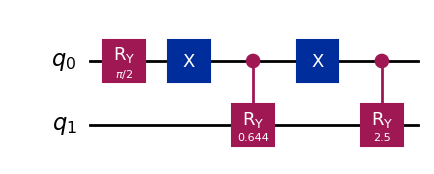

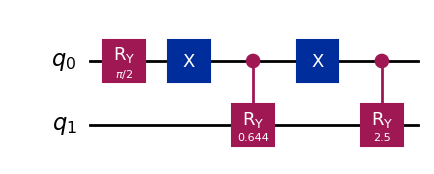

In [73]:
import pylatexenc
%matplotlib inline 
import matplotlib.pyplot as plt 
from IPython import display 
from qiskit.visualization import circuit_drawer

# Preprocessing circuit
thetas, all_combinations = thetas_computation(example_matrix, debug = False)
matrix_circuit = generate_qram_circuit(thetas, all_combinations, example_matrix)
matrix_circuit.draw("mpl")

In [74]:
# Preprocessing circuit
#import matplotlib.pyplot as plt

#def visualize_quantum_circuit(circuit, figsize=(12, 6), scale=0.7):
    #"""Helper function to visualize quantum circuits with consistent styling"""
    #try:
        #fig, ax = plt.subplots(figsize=figsize)
        # Return the figure object from circuit_drawer
       # circuit_drawing = circuit_drawer(circuit, output='mpl', scale=scale, ax=ax)
        #plt.tight_layout()
       # return circuit_drawing  # Return the figure for display
    #except Exception as e:
        #print(f"Visualization error: {e}")
        # Try text output as fallback
       # print("Fallback to text representation:")
       #print(circuit)
    #finally:
        #plt.close(fig)
   #

# Configure Jupyter

#plt.style.use('default')

# Generate and visualize circuit
#thetas, all_combinations = thetas_computation(example_matrix, debug=False)
#matrix_circuit = generate_qram_circuit(thetas, all_combinations, example_matrix)

# Display the circuit
#fig = visualize_quantum_circuit(matrix_circuit)
#if fig is not None:  # Only try to display if we got a figure back
    #display.display(fig)

#show the figure 

#display.display(fig)


In [75]:
#from qiskit_aer.primitives import StatevectorEstimator
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit import transpile

simulator = AerSimulator(method='statevector')
matrix_circuit_with_measure = matrix_circuit.copy()
matrix_circuit_with_measure.measure_all()
job = simulator.run(transpile(matrix_circuit_with_measure, simulator))
counts = job.result().get_counts()
print("Counts:", counts)


Counts: {'01': 53, '10': 49, '00': 472, '11': 450}


In [76]:
#PHASE ESTIMATIOn

# Create and Add Phase estimation block to circuit
resolution = 4
pe_circuit = my_phase_estimation(example_matrix, matrix_circuit, resolution)



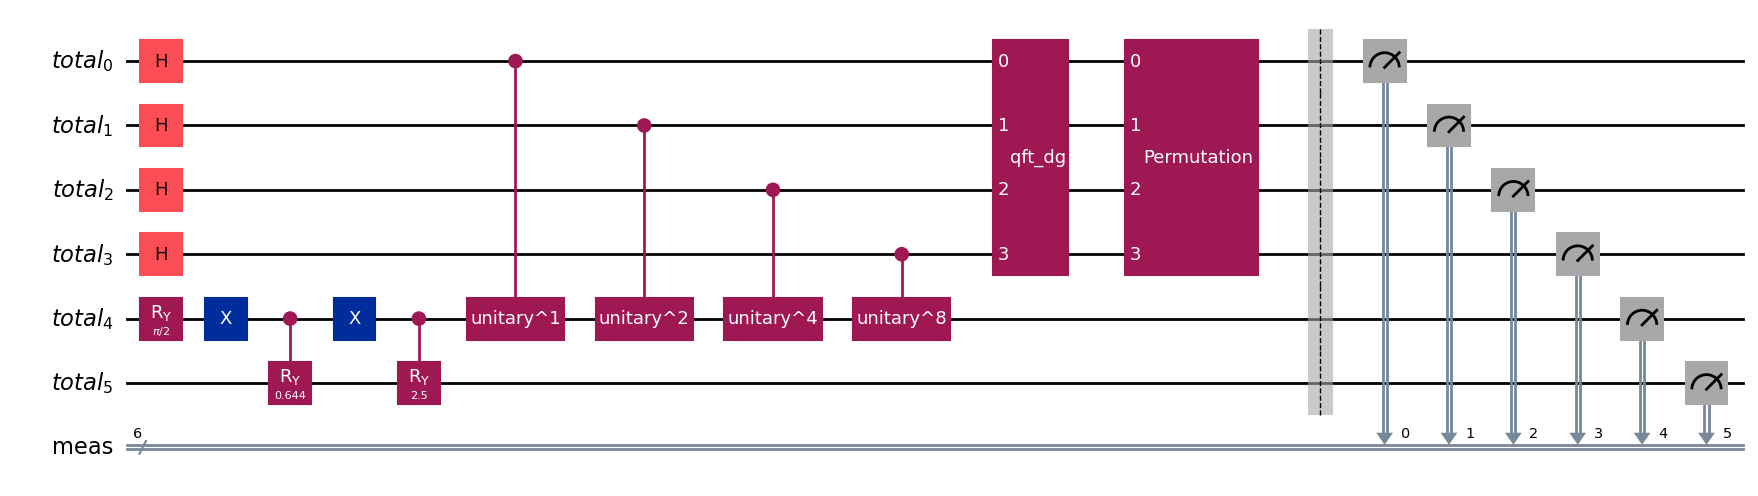

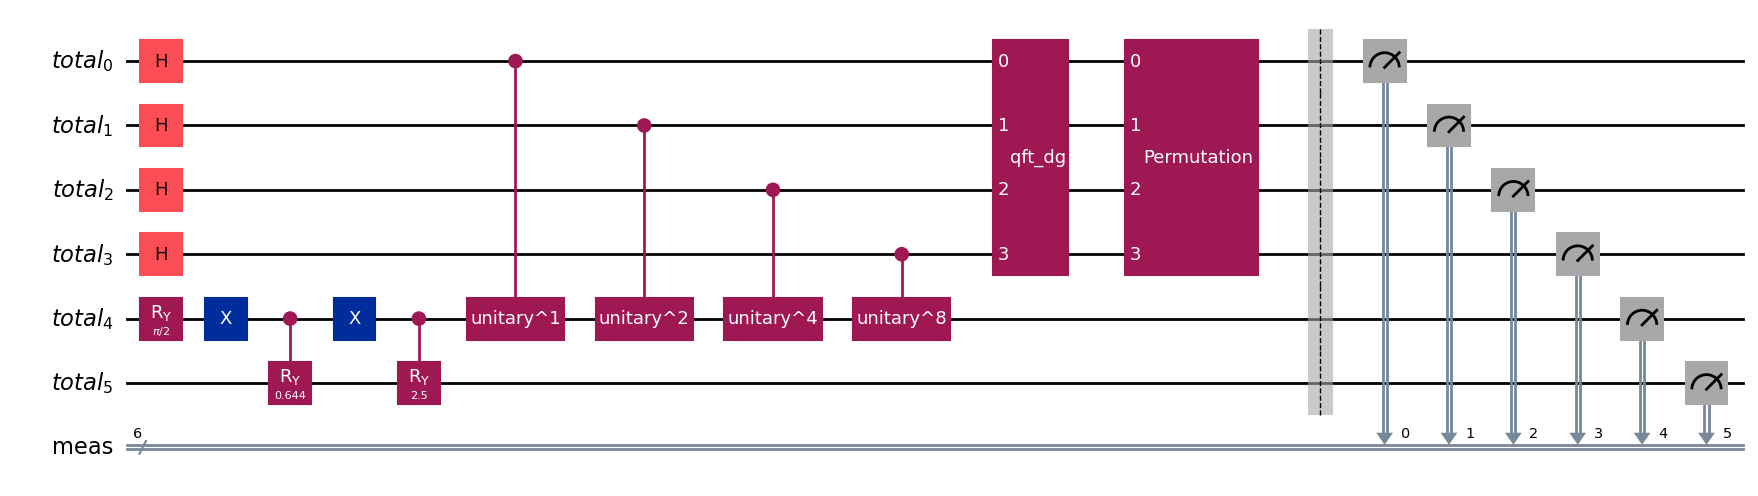

In [77]:
pe_circuit.measure_all()
# print(exact_statevector)
pe_circuit.decompose(reps=1).draw("mpl")

Total counts: 57
Max count value: 2506


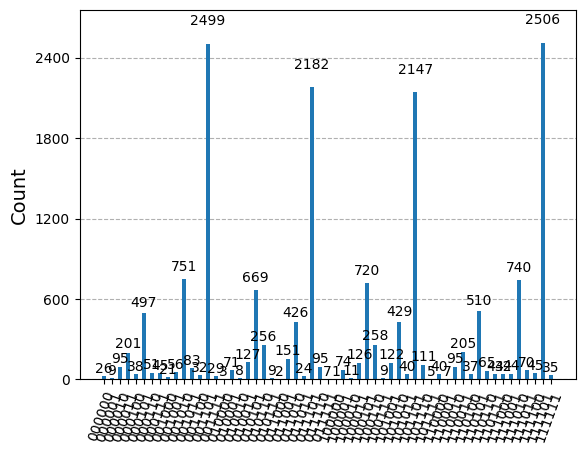

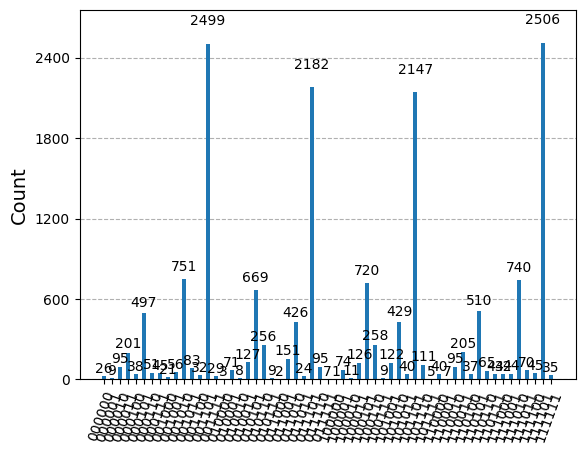

In [78]:
#QUANTUM STATE TOMOGRPAHY 
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram


n_shots = 17000 # Increase to achieve higher accuracy
backend_simulation = AerSimulator()
job = backend_simulation.run(transpile(pe_circuit, backend_simulation), shots=n_shots)
counts = job.result().get_counts()
print("Total counts:", len(counts))
print("Max count value:", max(counts.values()) if counts else 0)
plot_histogram(counts)

In [79]:
# Reconstruct the probabilities of observing each state from the counts provided by the simulation, plus perform the sign tomography
from qiskit.circuit import ClassicalRegister
probabilities = {}

for i in range(2**pe_circuit.num_qubits):
    binary_i = bin(i)[2:].zfill(pe_circuit.num_qubits)
    try:
        # Will approximate the modulus two of the values seen in exact_statevector, two cells above
        probabilities[binary_i] = counts[binary_i]/n_shots
    except KeyError:
        probabilities[binary_i] = 0.0

sign_dictionary = sign_estimation(pe_circuit, probabilities, n_shots)

Number of ops in circuit_to_control BEFORE decomposition: 2
After decomposition pass 1, num ops: 15
After decomposition pass 2, num ops: 33
After decomposition pass 3, num ops: 77
--- circuit_to_control AFTER decomposition (inspect for 'permutation'): ---
          ┌─────────────┐                                                                                      »
total_0: ─┤ U3(π/2,0,π) ├──────────────────────────────────────────────────────────────────────────────────────»
          ├─────────────┤                                                                                      »
total_1: ─┤ U3(π/2,0,π) ├──────────────────────────────────────────────────────────────────────────────────────»
          ├─────────────┤                                                                                      »
total_2: ─┤ U3(π/2,0,π) ├──────────────────────────────────────────────────────────────────────────────────────»
          ├─────────────┤                                         

In [80]:
#simulator = AerSimulator(method='statevector')
#matrix_circuit = generate_qram_circuit(thetas, all_combinations, example_matrix)

#state = matrix_circuit.save_statevector() # Tell the simulator to save the statevector
##print(state)

# Transpile the circuit for the simulator
#transpiled_circuit_sv = transpile(matrix_circuit, simulator)

# Run the simulation
#job_sv = simulator.run(transpiled_circuit_sv)
#result_sv = job_sv.result()
#statevector = result_sv.get_statevector()

#print("Statevector from AerSimulator:")
#print(statevector)

In [81]:

# Create and Add Phase estimation block to circuit
resolution = 2 #this can be played wait 
pe_circuit = my_phase_estimation(example_matrix, matrix_circuit,resolution )
# For running the simulation with measurements
pe_circuit.measure_all()  # Add measurements to all qubits
# Create the simulator properly for Qiskit 1.4.1
from qiskit_aer import AerSimulator
backend_simulation = AerSimulator()  # Use the default method
# Run the simulation
n_shots = 17000 #change the shots maybe 
job = backend_simulation.run(transpile(pe_circuit, backend_simulation), shots=n_shots) # uughhhhhhhhhhh backend simulation no longer exists like this 
counts = job.result().get_counts()

#### Phase Estimation

In [82]:
# Create and Add Phase estimation block to circuit
resolution = 5
pe_circuit = my_phase_estimation(example_matrix, matrix_circuit, resolution)

Gate: circuit-2696, Qubits: [Qubit(QuantumRegister(7, 'total'), 5), Qubit(QuantumRegister(7, 'total'), 6)]
Gate: QPE, Qubits: [Qubit(QuantumRegister(7, 'total'), 0), Qubit(QuantumRegister(7, 'total'), 1), Qubit(QuantumRegister(7, 'total'), 2), Qubit(QuantumRegister(7, 'total'), 3), Qubit(QuantumRegister(7, 'total'), 4), Qubit(QuantumRegister(7, 'total'), 5)]
Gate: barrier, Qubits: [Qubit(QuantumRegister(7, 'total'), 0), Qubit(QuantumRegister(7, 'total'), 1), Qubit(QuantumRegister(7, 'total'), 2), Qubit(QuantumRegister(7, 'total'), 3), Qubit(QuantumRegister(7, 'total'), 4), Qubit(QuantumRegister(7, 'total'), 5), Qubit(QuantumRegister(7, 'total'), 6)]
Gate: measure, Qubits: [Qubit(QuantumRegister(7, 'total'), 0)]
Gate: measure, Qubits: [Qubit(QuantumRegister(7, 'total'), 1)]
Gate: measure, Qubits: [Qubit(QuantumRegister(7, 'total'), 2)]
Gate: measure, Qubits: [Qubit(QuantumRegister(7, 'total'), 3)]
Gate: measure, Qubits: [Qubit(QuantumRegister(7, 'total'), 4)]
Gate: measure, Qubits: [Qub

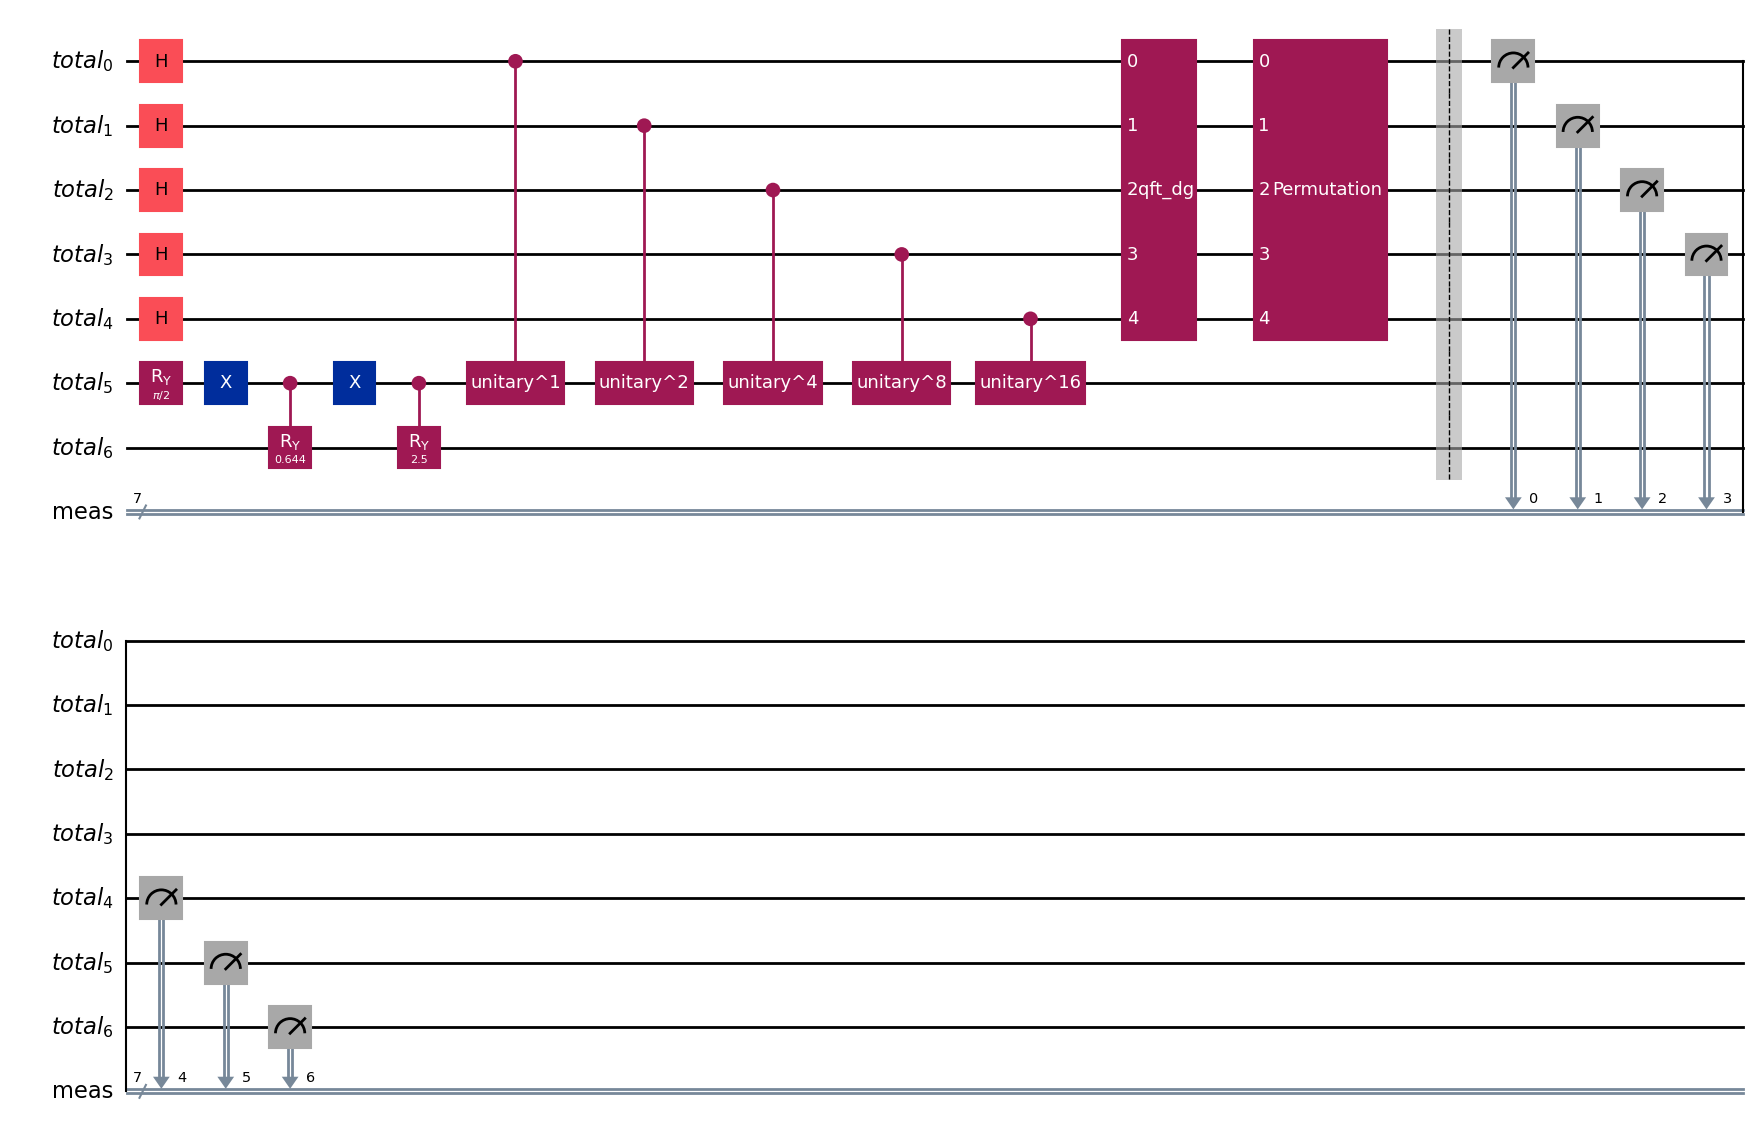

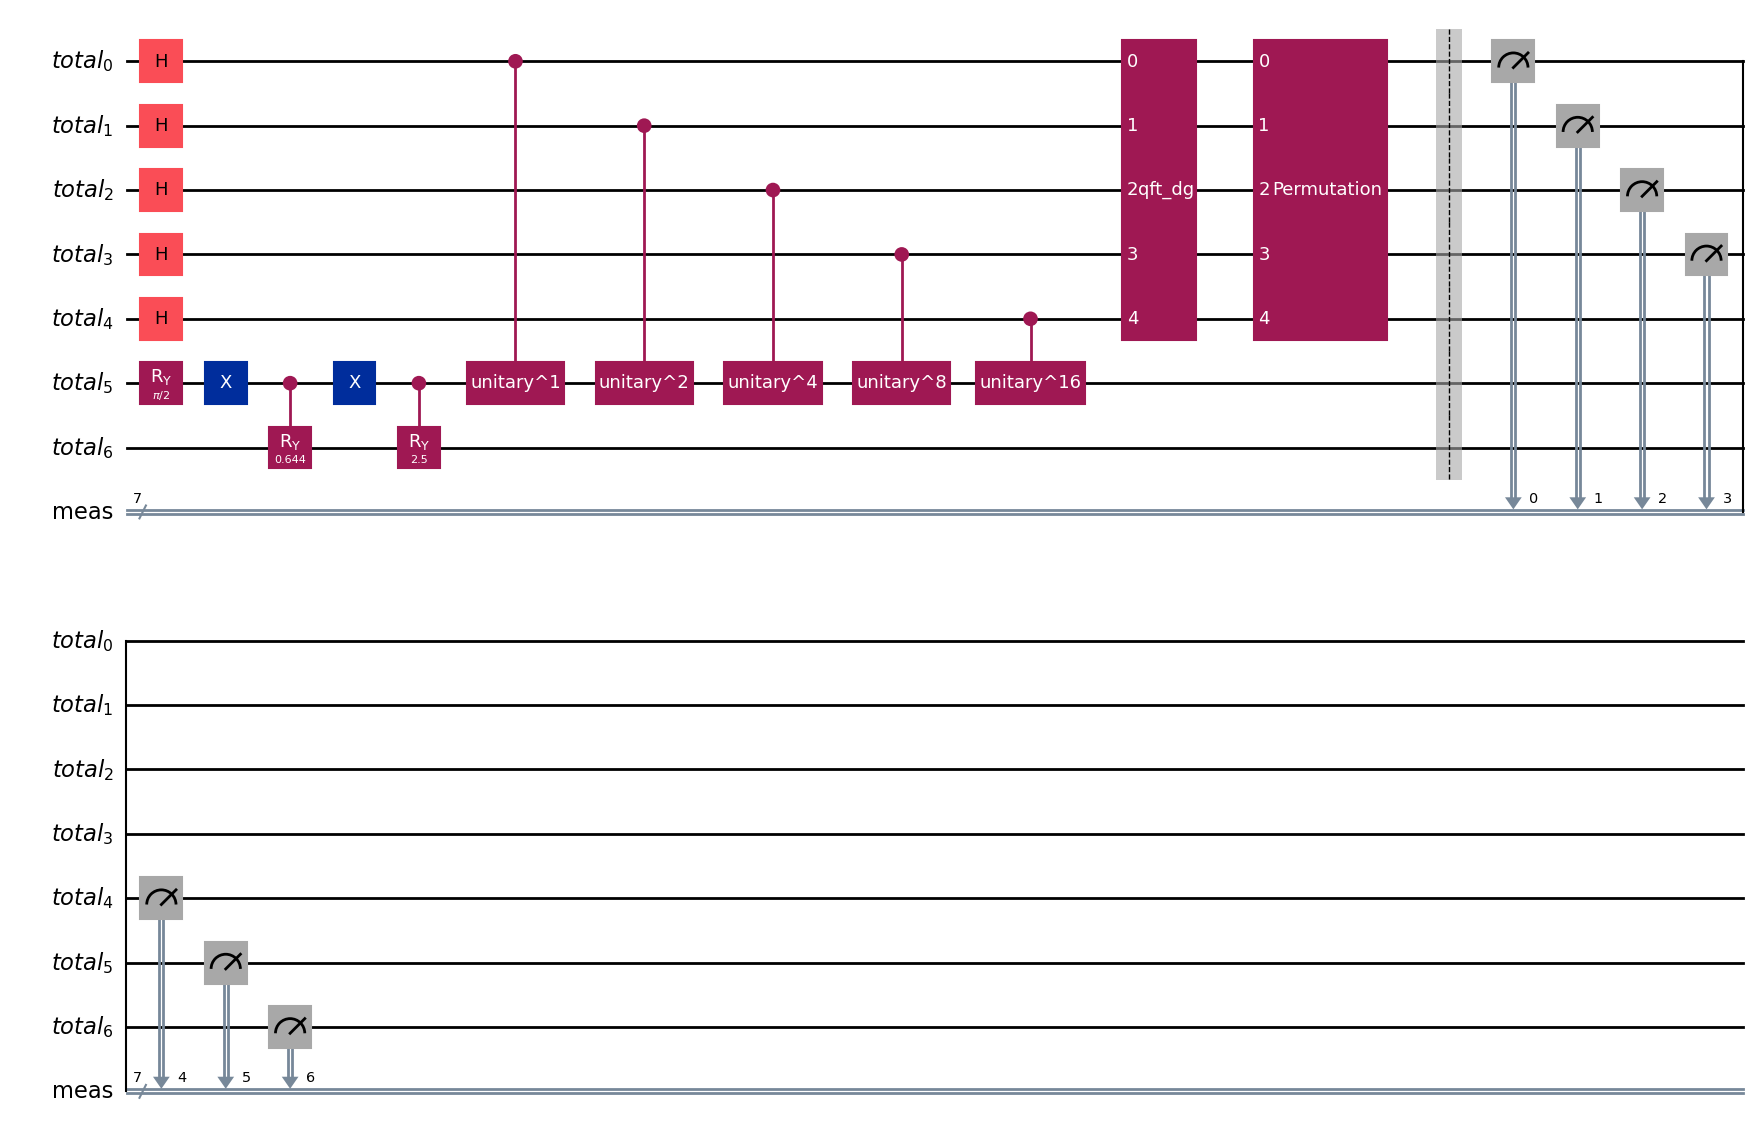

In [83]:
# Check that the circuit correctly estimates the eigenvalues 
# (only the states associated to the correct eigenvalues have probability amplitude different from 0)
# exact_statevector = check_statevector(backend,pe_circuit,resolution,example_matrix)
pe_circuit.measure_all()
for instruction in pe_circuit.data:
    print(f"Gate: {instruction[0].name}, Qubits: {instruction[1]}")
# print(exact_statevector)
pe_circuit.decompose(reps=1).draw("mpl")


#### Quantum State Tomography

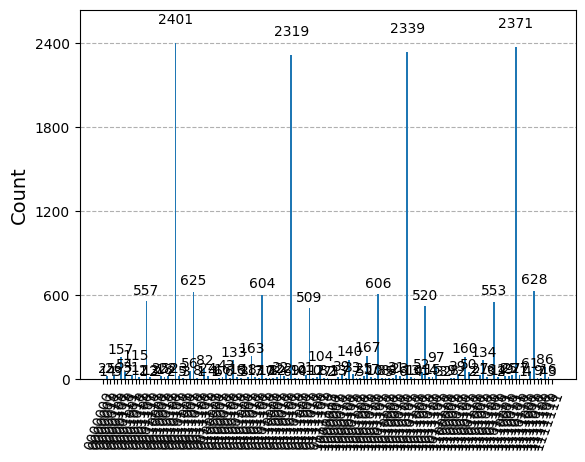

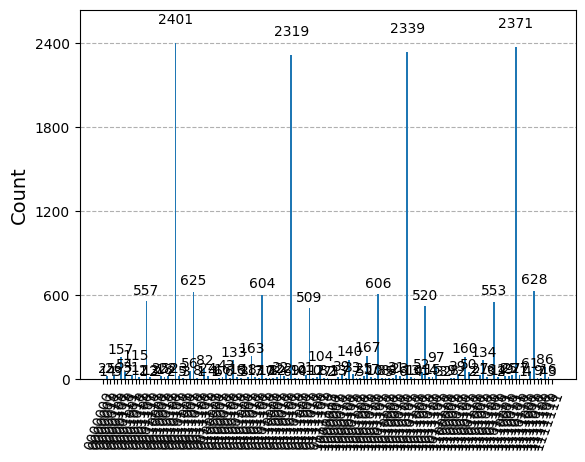

In [84]:
# Run the circuit using qiskit simulator
n_shots = 17000  # Increase to achieve higher accuracy

# Use AerSimulator from qiskit_aer instead of Aer.get_backend
from qiskit_aer import AerSimulator
backend_simulation = AerSimulator()  # Creates a QASM simulator by default

# Run the simulation (note: no "backend=" parameter needed)
job = backend_simulation.run(transpile(pe_circuit, backend_simulation), shots=n_shots)
counts = job.result().get_counts()
#so its not super crowded and ugly 
#filtered_counts = {k: v for k, v in counts.items() if v > 1000}
#plot_histogram(filtered_counts)


# Visualize results if needed
from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [85]:
# First, let's check what's actually in the counts dictionary
print("Example keys in counts:", list(counts.keys())[:3])
print("Format of first key:", [len(key.split()) for key in list(counts.keys())[:1]])

# Reconstruct probabilities directly since keys are already in the right format
probabilities = {}
for bitstring, count in counts.items():
    probabilities[bitstring] = count/n_shots

print("Number of non-zero entries:", len(probabilities))
print("Sum of probabilities:", sum(probabilities.values()))

# Ensure we have all bit strings in the probabilities dictionary
for i in range(2**pe_circuit.num_qubits):
    binary_i = bin(i)[2:].zfill(pe_circuit.num_qubits)
    if binary_i not in probabilities: 
        probabilities[binary_i] = 0.0

# Normalize probabilities
norm_factor = sum(probabilities.values())
if norm_factor > 1e-10:
    probabilities = {k: v/norm_factor for k, v in probabilities.items()}
    print("After normalization, sum =", sum(probabilities.values()))


n_shots = 1000000 #i added this to increase shot amount because probavility at 17000 was 56.2 and 43.8% only minor change 
# Now proceed with sign estimation
sign_dictionary = sign_estimation(pe_circuit, probabilities, n_shots)

Example keys in counts: ['1101000', '0100000', '1011110']
Format of first key: [1]
Number of non-zero entries: 125
Sum of probabilities: 1.0
After normalization, sum = 1.0
Number of ops in circuit_to_control BEFORE decomposition: 2
After decomposition pass 1, num ops: 17
After decomposition pass 2, num ops: 40
After decomposition pass 3, num ops: 103
--- circuit_to_control AFTER decomposition (inspect for 'permutation'): ---
          ┌─────────────┐                                                                                      »
total_0: ─┤ U3(π/2,0,π) ├──────────────────────────────────────────────────────────────────────────────────────»
          ├─────────────┤                                                                                      »
total_1: ─┤ U3(π/2,0,π) ├──────────────────────────────────────────────────────────────────────────────────────»
          ├─────────────┤                                                                                      »
total_

#### Results

In [86]:
print("Quantum method results:")
result = eigen_estimation(probabilities, sign_dictionary, resolution, debug=False)
eigenvalues = []
eigenvectors = []
for eig, eigenvector in result:
    print(f'eigenvalue: {eig*norm_factor} - eigenvector: {np.real(eigenvector).round(3)}')
    eigenvalues.append(eig*norm_factor)
    eigenvectors.append(list(eigenvector))

Quantum method results:
eigenvalue: 0.34375 - eigenvector: [0.652 0.724]
eigenvalue: 0.65625 - eigenvector: [0.698 0.71 ]


In [87]:
original_matrix = example_matrix*norm_factor
reduced_matrix = transform(original_matrix, eigenvalues, eigenvectors)
reduced_matrix.round(3)

array([[0.762, 0.577],
       [0.803, 0.582]])

Note: 

1) The signs of the eigenvectors are arbitrary. 
You can flip them without changing the meaning of ther result; only their direction matters.

2) One can improve the accuracy of the algorithm increasing the *resolution* parameter and the number of shots

In [88]:
print("Classically computed values:") #normalized matrix 
eigenvalues, eigenvectors = np.linalg.eig(example_matrix)
zipped_list = list(zip(eigenvalues, eigenvectors.T))  # .T to get columns as rows
cl_eigenvalues = []
cl_eigenvectors = []
for eigenval, eigenvec in sorted(zipped_list, key = lambda x: x[0]):
    print(f'eigenvalue: {eigenval:.0f} - eigenvector: {eigenvec.round(3)}')
    cl_eigenvalues.append(eigenval)
    cl_eigenvectors.append(list(eigenvec))

Classically computed values:
eigenvalue: 0 - eigenvector: [-0.707  0.707]
eigenvalue: 1 - eigenvector: [0.707 0.707]


In [89]:
print("Classically computed values:")
eigenvalues, eigenvectors = np.linalg.eig(example_matrix)
zipped_list = list(zip(eigenvalues, eigenvectors.T))  # .T to get columns as rows
cl_eigenvalues = []
cl_eigenvectors = []
for eigenval, eigenvec in sorted(zipped_list, key = lambda x: x[0]):
    print(f'eigenvalue: {eigenval} - eigenvector: {eigenvec}')
    cl_eigenvalues.append(eigenval)
    cl_eigenvectors.append(list(eigenvec))


    

Classically computed values:
eigenvalue: 0.33333333333333337 - eigenvector: [-0.70710678  0.70710678]
eigenvalue: 0.6666666666666666 - eigenvector: [0.70710678 0.70710678]


In [90]:
print("Classically computed values:")
eigenvalues, eigenvectors = np.linalg.eig(original_matrix)
zipped_list = list(zip(eigenvalues, eigenvectors.T))  # .T to get columns as rows
cl_eigenvalues = []
cl_eigenvectors = []
for eigenval, eigenvec in sorted(zipped_list, key = lambda x: x[0]):
    print(f'eigenvalue: {eigenval} - eigenvector: {eigenvec}')
    cl_eigenvalues.append(eigenval)
    cl_eigenvectors.append(list(eigenvec))


Classically computed values:
eigenvalue: 0.33333333333333337 - eigenvector: [-0.70710678  0.70710678]
eigenvalue: 0.6666666666666666 - eigenvector: [0.70710678 0.70710678]


In [91]:
classically_reduced_matrix = transform(example_matrix, cl_eigenvalues, cl_eigenvectors)
classically_reduced_matrix.round(3)

array([[-0.408,  0.577],
       [ 0.408,  0.577]])

In [92]:
from scipy.linalg import expm 
from qiskit.circuit.library import QFTGate
from qiskit.circuit.library import phase_estimation 

'''def my_phase_estimation(matrix, qram_circuit, resolution):
    # Create the unitary operator using matrix exponential
    #U = expm(matrix * (2 * np.pi * 1j))
    U = expm(2 * np.pi * 1j * example_matrix)
    # Create the Operator object from U
    u_operator = Operator(U)
    
    # Convert the operator to a UnitaryGate
    u_gate = u_operator.to_instruction()
    
    # Print dimensions for debugging
    print(f"Matrix dimensions: {matrix.shape}")
    print(f"Unitary gate qubits: {u_gate.num_qubits}")
    print(f"QRAM circuit qubits: {qram_circuit.num_qubits}")
    
    # Create registers matching QRAM circuit size
    eval_register = QuantumRegister(resolution, 'eval')
    state_register = QuantumRegister(qram_circuit.num_qubits, 'state')
    
    # Create the main circuit with both registers
    pe_circuit = QuantumCircuit(eval_register, state_register)
    
    # First prepare the state using the QRAM circuit
    pe_circuit.append(qram_circuit.to_gate(), state_register)
    
    # Apply the phase estimation algorithm manually
    # Step 1: Apply Hadamard to all evaluation qubits
    for i in range(resolution):
        pe_circuit.h(eval_register[i])
    
    # Step 2: Apply controlled-unitary operations with increasing powers
    for i in range(resolution):
        # Apply 2^i controlled applications of the unitary
        # Make sure we're applying to the right number of qubits
        control_qubit = [eval_register[i]]
        target_qubits = list(state_register)
        
        # Create a controlled version of the unitary that matches the state register size
        if u_gate.num_qubits != len(target_qubits):
            #create a unitary that matches our state register size
            expanded_unitary = np.kron(U, np.eye(2**(len(target_qubits) - u_gate.num_qubits)))
            controlled_u = Operator(expanded_unitary).to_instruction().control(1)
        else:
            controlled_u = u_gate.control(1)
        
        for _ in range(2**i):
            pe_circuit.append(controlled_u, control_qubit + target_qubits)
    
    # Step 3: Apply inverse QFT to the evaluation register
    from qiskit.circuit.library import QFTGate
    pe_circuit.append(QFTGate(resolution).inverse(), eval_register)
    
    return pe_circuit

def check_statevector(backend, pe_circuit, resolution, example_matrix):
    pe_job = backend.run(transpile(pe_circuit, backend=backend))
    statevector = np.asarray(pe_job.result().get_statevector()).round(3)

    bitstrings = [''.join([''.join(str(j)) for j in i]) for i in list(map(list, itertools.product([0, 1], repeat=resolution+len(example_matrix))))]
    statevector_dict = {}
    for bitstring, amplitude in zip(bitstrings, statevector):
        statevector_dict[bitstring] = amplitude
    return statevector_dict'''

'def my_phase_estimation(matrix, qram_circuit, resolution):\n    # Create the unitary operator using matrix exponential\n    #U = expm(matrix * (2 * np.pi * 1j))\n    U = expm(2 * np.pi * 1j * example_matrix)\n    # Create the Operator object from U\n    u_operator = Operator(U)\n    \n    # Convert the operator to a UnitaryGate\n    u_gate = u_operator.to_instruction()\n    \n    # Print dimensions for debugging\n    print(f"Matrix dimensions: {matrix.shape}")\n    print(f"Unitary gate qubits: {u_gate.num_qubits}")\n    print(f"QRAM circuit qubits: {qram_circuit.num_qubits}")\n    \n    # Create registers matching QRAM circuit size\n    eval_register = QuantumRegister(resolution, \'eval\')\n    state_register = QuantumRegister(qram_circuit.num_qubits, \'state\')\n    \n    # Create the main circuit with both registers\n    pe_circuit = QuantumCircuit(eval_register, state_register)\n    \n    # First prepare the state using the QRAM circuit\n    pe_circuit.append(qram_circuit.to_gate()

In [93]:
#Qiskit Algorithms 0.3.1

#!pip install qiskit_algorithms==0.3.1
#from qiskit.utils import algorithm_globals
#algorithm_globals.random_seed = 101


import numpy

from qiskit.circuit import QuantumCircuit, QuantumRegister
from qiskit.circuit.classicalregister import ClassicalRegister
from qiskit.primitives import BaseSampler

from qiskit_algorithms.exceptions import AlgorithmError

from qiskit_algorithms.phase_estimators import ipe




